# FINN3021 — Portfolio Dashboard

**Inception:** 9 March 2026 · **Horizon:** ~10 years · **Analysis cut-off:** 20 April 2026

**Allocation:** 85% equity (20 names, equal-weight) · 15% short-duration bonds (BIL)

**Benchmark:** MSCI ACWI ex-US (ACWX) · **No rebalancing**

---

Run top to bottom. All prices pulled live via `yfinance`.

## 0 · Imports & config

In [20]:
%pip install --quiet yfinance pandas numpy matplotlib seaborn tabulate scipy statsmodels

Note: you may need to restart the kernel to use updated packages.


In [21]:
import pathlib, warnings
from datetime import date, datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import yfinance as yf
from tabulate import tabulate
from scipy import stats as sp_stats

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 140

ROOT = pathlib.Path().resolve().parent
OUT  = ROOT / "data" / "outputs"; OUT.mkdir(parents=True, exist_ok=True)

# ── Dates ──────────────────────────────────────────────────────
INCEPTION   = date(2026, 3, 9)
ANALYSIS_END = date(2026, 4, 20)   # cut-off for graded analysis
HORIZON_YRS = 10
RISK_FREE_ANNUAL = 0.043           # approx 1-3m T-bill yield

# ── Allocation ────────────────────────────────────────────────
BENCHMARK   = "ACWX"              # MSCI ACWI ex-US ETF

print(f"inception: {INCEPTION}  |  analysis end: {ANALYSIS_END}")
print(f"allocation: 100% equity (conviction-weighted, no bond sleeve)")
print(f"benchmark: {BENCHMARK}")

inception: 2026-03-09  |  analysis end: 2026-04-20
allocation: 100% equity (conviction-weighted, no bond sleeve)
benchmark: ACWX


## 1 · Holdings definition

In [ ]:
HOLDINGS = pd.DataFrame([
    # ── Tier 1 — Near-certainties (~8% each) ─────────────────
    {"name": "AutoTrader",       "ticker": "AUTO.L",      "country": "GB", "sector": "Comm Svcs",       "tier": 1, "thesis": "0.94 quality, 52.4% FCF margin, 28.8% ROIC floor, platform monopoly, zero debt"},
    {"name": "Kakaku.com",       "ticker": "2371.T",      "country": "JP", "sector": "Comm Svcs",       "tier": 1, "thesis": "0.85 persistence, 58.7% ROIC floor, 32.3% FCF margin, zero debt, platform monopoly"},
    {"name": "Clicks Group",     "ticker": "CLS.JO",      "country": "ZA", "sector": "Cons Staples",    "tier": 1, "thesis": "34.9% ROIC floor, pharmacy/health retail, structural demand, zero flags"},
    {"name": "ITC",              "ticker": "ITC.NS",      "country": "IN", "sector": "Cons Staples",    "tier": 1, "thesis": "26.1% ROIC floor, 0.80 durability, zero debt, ESG forced-seller mispricing"},
    {"name": "Odontoprev",       "ticker": "ODPV3.SA",    "country": "BR", "sector": "Healthcare",      "tier": 1, "thesis": "46.9% ROIC floor, 0.89 quality, 28.2% FCF margin, zero debt, dental insurance"},
    {"name": "Games Workshop",   "ticker": "GAW.L",       "country": "GB", "sector": "Cons Disc",       "tier": 1, "thesis": "0.92 quality, 77.6% ROIC, 32.5% ROIC floor, irreplaceable IP moat"},
    # ── Tier 2 — High confidence (~4.5% each) ───────────────
    {"name": "Next PLC",         "ticker": "NXT.L",       "country": "GB", "sector": "Cons Disc",       "tier": 2, "thesis": "0.78 franchise, Piotroski 8, Total Platform transformation, buybacks"},
    {"name": "Crompton Greaves", "ticker": "CROMPTON.NS", "country": "IN", "sector": "Cons Disc",       "tier": 2, "thesis": "0.87 franchise, 16.4% ROIC floor, zero debt, Indian consumer electricals"},
    {"name": "Recruit Holdings", "ticker": "6098.T",      "country": "JP", "sector": "Industrials",     "tier": 2, "thesis": "Indeed platform monopoly, zero debt, -11% share change buybacks"},
    {"name": "Largan Precision", "ticker": "3008.TW",     "country": "TW", "sector": "Info Tech",       "tier": 2, "thesis": "30.6% ROIC floor, 36.9% FCF margin, zero debt, smartphone lens dominance"},
    {"name": "HM Sampoerna",     "ticker": "HMSP.JK",     "country": "ID", "sector": "Cons Staples",    "tier": 2, "thesis": "0.81 quality, 22.3% ROIC floor, zero debt, 7.2% div yield, ESG mispricing"},
    {"name": "King Slide Works", "ticker": "2059.TW",     "country": "TW", "sector": "Industrials",     "tier": 2, "thesis": "0.91 quality, 45.8% ROIC floor, 41.9% FCF margin, data centre tailwind"},
    {"name": "Kimberly-Clark MX","ticker": "KIMBERA.MX",  "country": "MX", "sector": "Cons Staples",    "tier": 2, "thesis": "0.85 quality, 19.8% ROIC floor, 13.81% FCF/EV yield, Piotroski 8"},
    {"name": "Mr Price",         "ticker": "MRP.JO",      "country": "ZA", "sector": "Cons Disc",       "tier": 2, "thesis": "0.81 franchise, 17.3% ROIC floor, 10.69% FCF/EV yield, genuinely cheap"},
    # ── Tier 3 — Compelling but conditional (~2% each) ───────
    {"name": "Technogym",        "ticker": "TGYM.MI",     "country": "IT", "sector": "Cons Disc",       "tier": 3, "thesis": "0.74 quality, 19.4% ROIC floor, zero debt, premium fitness brand moat"},
    {"name": "Ipsen",            "ticker": "IPN.PA",      "country": "FR", "sector": "Healthcare",      "tier": 3, "thesis": "Specialty pharma, oncology pipeline, no mega-cap bloat, mid-cap compounder"},
    {"name": "Maruwa Co",        "ticker": "5344.T",      "country": "JP", "sector": "Info Tech",       "tier": 3, "thesis": "12.07% FCF/EV yield, zero debt, advanced ceramics for semis"},
    {"name": "Rational AG",      "ticker": "RAA.DE",      "country": "DE", "sector": "Industrials",     "tier": 3, "thesis": "55.4% ROIC, 30.1% floor, zero debt, commercial kitchen hidden champion"},
    {"name": "Dormakaba",        "ticker": "DOKA.SW",     "country": "CH", "sector": "Industrials",     "tier": 3, "thesis": "Three style tags neglect, 7.34% FCF/EV yield, merger integration upside"},
    {"name": "Bumrungrad",       "ticker": "BH.BK",       "country": "TH", "sector": "Healthcare",      "tier": 3, "thesis": "40% ROIC, 24.5% FCF margin, zero debt, Thai medical tourism leader"},
    {"name": "SADAFCO",          "ticker": "2270.SR",     "country": "SA", "sector": "Cons Staples",    "tier": 3, "thesis": "Dominant Saudi dairy, cold-chain moat, zero debt, durability driver"},
    {"name": "Petronet LNG",     "ticker": "PETRONET.NS", "country": "IN", "sector": "Energy",          "tier": 3, "thesis": "28.1% ROIC, zero debt, toll-road on Indian energy demand"},
])

N_STOCKS = len(HOLDINGS)

# Conviction-weighted allocation (100% equity)
TIER_WEIGHTS = {1: 0.08, 2: 0.045, 3: 0.02}  # of total portfolio
HOLDINGS["eq_weight"] = HOLDINGS["tier"].map(TIER_WEIGHTS)

print(f"{N_STOCKS} holdings across 3 conviction tiers — 100% equity")
print(f"Equity total: {HOLDINGS['eq_weight'].sum():.0%}")
print(f"Tier weights: T1={TIER_WEIGHTS[1]:.0%}, T2={TIER_WEIGHTS[2]:.1%}, T3={TIER_WEIGHTS[3]:.0%}")
print()
print(tabulate(HOLDINGS[["name","ticker","country","sector","tier","eq_weight"]],
               headers="keys", tablefmt="simple", showindex=False, floatfmt=".3%"))

22 holdings across 3 conviction tiers — 100% equity
Equity total: 100%
Tier weights: T1=8%, T2=4.5%, T3=2%

name               ticker       country    sector          tier    eq_weight
-----------------  -----------  ---------  ------------  ------  -----------
AutoTrader         AUTO.L       GB         Comm Svcs          1       8.000%
Kakaku.com         2371.T       JP         Comm Svcs          1       8.000%
Clicks Group       CLS.JO       ZA         Cons Staples       1       8.000%
ITC                ITC.NS       IN         Cons Staples       1       8.000%
Odontoprev         ODPV3.SA     BR         Healthcare         1       8.000%
Games Workshop     GAW.L        GB         Cons Disc          1       8.000%
Next PLC           NXT.L        GB         Cons Disc          2       4.500%
Crompton Greaves   CROMPTON.NS  IN         Cons Disc          2       4.500%
Recruit Holdings   6098.T       JP         Industrials        2       4.500%
Largan Precision   3008.TW      TW         In

## 2 · Screen fundamentals (from 01_screen output)

In [23]:
# Load the full screen output and filter to our holdings
screen_all = pd.read_csv(ROOT / "data" / "outputs" / "portfolio_screen_final20.csv")

# Map screen names → our tickers (only names present in the screen CSV)
_NAME_MAP = {
    "AUTOTRADER GROUP PLC":          "AUTO.L",
    "KAKAKU.COM INC":                "2371.T",
    "CLICKS GROUP LTD":              "CLS.JO",
    "ITC LTD":                       "ITC.NS",
    "ODONTOPREV SA":                 "ODPV3.SA",
    "NEXT PLC":                      "NXT.L",
    "CROMPTON GREAVES CONSUMER":     "CROMPTON.NS",
    "RECRUIT HOLDINGS CO LTD":       "6098.T",
    "HANJAYA MANDALA SAMPOERNA":     "HMSP.JK",
    "KIMBERLY-CLARK DE MEXICO SA":   "KIMBERA.MX",
    "MR PRICE GROUP LTD":            "MRP.JO",
    "ROCHE HOLDING AG":              "ROG.SW",
    "MARUWA CO LTD":                 "5344.T",
    "DORMAKABA HOLDINGS AG":         "DOKA.SW",
    "BUMRUNGRAD HOSPITAL PCL":       "BH.BK",
}
screen_all["ticker"] = screen_all["company_name"].map(_NAME_MAP)
fundamentals = screen_all[screen_all["ticker"].notna()].copy()

fund_cols = ["ticker", "company_name", "rk", "fic", "gsector",
             "piotroski", "roic_5y_avg", "fcf_ev_5y_avg", "fcf_growth_5y",
             "div_yield", "pe_ratio", "net_debt_ebitda", "altman_z",
             "composite", "cheap_block", "quality_block", "persist_block",
             "fcf_pos_years_10y", "roic_min_10y", "driver"]
fund_cols = [c for c in fund_cols if c in fundamentals.columns]
fundamentals = fundamentals[fund_cols].set_index("ticker")

# Format for display
fund_show = fundamentals.copy()
for c in ["roic_5y_avg", "fcf_ev_5y_avg", "fcf_growth_5y", "div_yield", "roic_min_10y"]:
    if c in fund_show.columns:
        fund_show[c] = (fund_show[c] * 100).round(1)
for c in ["composite", "cheap_block", "quality_block", "persist_block", "net_debt_ebitda", "altman_z"]:
    if c in fund_show.columns:
        fund_show[c] = fund_show[c].round(2)
if "pe_ratio" in fund_show.columns:
    fund_show["pe_ratio"] = fund_show["pe_ratio"].round(1)

print(f"Matched {len(fundamentals)} / {N_STOCKS} holdings to screen output")
print("(7 stocks added outside screen: GAW.L, 3008.TW, 2059.TW, TGYM.MI, RAA.DE, 2270.SR, PETRONET.NS)")
fund_show

Matched 15 / 22 holdings to screen output
(7 stocks added outside screen: GAW.L, 3008.TW, 2059.TW, TGYM.MI, RAA.DE, 2270.SR, PETRONET.NS)


,company_name,rk,fic,gsector,piotroski,roic_5y_avg,fcf_ev_5y_avg,div_yield,pe_ratio,net_debt_ebitda,altman_z,composite,quality_block,persist_block,fcf_pos_years_10y,roic_min_10y,driver
ticker,,,,,,,,,,,,,,,,,
CLS.JO,CLICKS GROUP LTD,1,ZA,30,8,40.0,4.4,5.7,11.2,0.12,3.10,0.73,0.87,0.57,10.0,34.9,quality
ODPV3.SA,ODONTOPREV SA,2,BR,35,8,54.8,11.1,7.0,12.8,0.00,5.51,0.72,0.89,0.53,10.0,46.9,quality
NXT.L,NEXT PLC,4,GB,25,8,26.0,6.9,2.4,17.5,1.07,6.20,0.70,0.76,0.62,10.0,11.8,franchise
AUTO.L,AUTOTRADER GROUP PLC,6,GB,50,9,45.2,4.1,3.0,14.1,0.00,20.21,0.77,0.94,0.58,10.0,28.8,quality
CROMPTON.NS,CROMPTON GREAVES CONSUMER,7,IN,25,8,24.9,3.1,1.2,27.9,0.00,4.42,0.70,0.75,0.64,10.0,16.4,franchise
2371.T,KAKAKU.COM INC,8,JP,50,6,82.8,5.0,2.8,17.9,0.00,9.41,0.73,0.67,0.85,10.0,58.7,franchise
6098.T,RECRUIT HOLDINGS CO LTD,9,JP,20,7,27.3,8.6,0.7,12.8,0.00,6.14,0.63,0.65,0.59,10.0,11.5,capital
HMSP.JK,HANJAYA MANDALA SAMPOERNA,11,ID,30,8,31.0,6.7,7.2,13.7,0.00,4.91,0.61,0.81,0.40,10.0,22.3,quality
DOKA.SW,DORMAKABA HOLDINGS AG,12,CH,20,6,24.3,7.3,18.2,22.2,0.84,1.95,0.53,0.49,0.60,10.0,13.9,capital


## 3 · Pull live price data

In [24]:
ALL_TICKERS = list(HOLDINGS["ticker"]) + [BENCHMARK]

# Pull from 1 day before inception to capture inception-day close
raw_prices = yf.download(
    ALL_TICKERS,
    start=(pd.Timestamp(INCEPTION) - pd.Timedelta(days=5)).strftime("%Y-%m-%d"),
    end=(pd.Timestamp(ANALYSIS_END) + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
    auto_adjust=True,
    progress=False,
)

# Extract close prices
if isinstance(raw_prices.columns, pd.MultiIndex):
    prices = raw_prices["Close"].copy()
else:
    prices = raw_prices[["Close"]].copy()
    prices.columns = ALL_TICKERS

# Forward-fill across market holidays (different exchanges have different calendars)
prices = prices.ffill()

# Trim to inception onward
prices = prices[prices.index >= pd.Timestamp(INCEPTION)].copy()

print(f"Price matrix: {prices.shape[0]} trading days × {prices.shape[1]} tickers")
print(f"Date range: {prices.index[0].date()} → {prices.index[-1].date()}")
print(f"\nMissing data check:")
miss = prices.isna().sum()
if miss.any():
    print(miss[miss > 0])
else:
    print("  None — all tickers have full coverage")

Price matrix: 34 trading days × 23 tickers
Date range: 2026-03-09 → 2026-04-17

Missing data check:
  None — all tickers have full coverage


## 4 · Portfolio construction (inception-day)

Assume $1,000,000 notional. Buy at inception-day close. No rebalancing. 100% equity, conviction-weighted.

In [25]:
NOTIONAL = 1_000_000

# ── 100% equity: conviction-weighted across 22 names ─────────
inception_prices = prices.iloc[0]  # first row = inception day

positions = pd.DataFrame({
    "ticker":        HOLDINGS["ticker"].values,
    "name":          HOLDINGS["name"].values,
    "country":       HOLDINGS["country"].values,
    "sector":        HOLDINGS["sector"].values,
    "tier":          HOLDINGS["tier"].values,
    "weight":        HOLDINGS["eq_weight"].values,
    "inception_px":  [inception_prices[t] for t in HOLDINGS["ticker"]],
    "cost_basis":    [NOTIONAL * w for w in HOLDINGS["eq_weight"]],
})
positions["shares"] = positions["cost_basis"] / positions["inception_px"]

print(f"Notional: ${NOTIONAL:,.0f}  — 100% equity, no bond sleeve")
print(f"Tier weights: T1={TIER_WEIGHTS[1]:.0%} × 6, T2={TIER_WEIGHTS[2]:.1%} × 8, T3={TIER_WEIGHTS[3]:.0%} × 8")
print(f"\nInception prices & allocations:")
print(tabulate(positions[["name","ticker","tier","weight","inception_px","shares","cost_basis"]],
               headers="keys", tablefmt="simple", showindex=False,
               floatfmt=(".0f", ".0f", ".0f", ".3%", ".2f", ".2f", ",.0f")))

Notional: $1,000,000  — 100% equity, no bond sleeve
Tier weights: T1=8% × 6, T2=4.5% × 8, T3=2% × 8

Inception prices & allocations:
name               ticker         tier    weight    inception_px    shares    cost_basis
-----------------  -----------  ------  --------  --------------  --------  ------------
AutoTrader         AUTO.L            1    8.000%          483.20    165.56        80,000
Kakaku.com         2371.T            1    8.000%         1782.98     44.87        80,000
Clicks Group       CLS.JO            1    8.000%        29595.00      2.70        80,000
ITC                ITC.NS            1    8.000%          306.00    261.44        80,000
Odontoprev         ODPV3.SA          1    8.000%           13.71   5835.16        80,000
Games Workshop     GAW.L             1    8.000%        16849.05      4.75        80,000
Next PLC           NXT.L             2    4.500%        12765.00      3.53        45,000
Crompton Greaves   CROMPTON.NS       2    4.500%          241.30  

## 5 · Daily portfolio value & returns

In [26]:
# ── Equity daily value per stock ─────────────────────────────
eq_tickers = list(HOLDINGS["ticker"])
shares_vec = positions.set_index("ticker")["shares"]

equity_values = prices[eq_tickers].multiply(shares_vec, axis=1)
port_value    = equity_values.sum(axis=1)

port_return = port_value / port_value.iloc[0] - 1

# ── Benchmark return ─────────────────────────────────────────
bench_return = prices[BENCHMARK] / prices[BENCHMARK].iloc[0] - 1

# ── Per-stock returns ────────────────────────────────────────
stock_returns = prices[eq_tickers] / prices[eq_tickers].iloc[0] - 1

# ── Daily log returns for risk calcs ─────────────────────────
port_daily_ret  = port_value.pct_change().dropna()
bench_daily_ret = prices[BENCHMARK].pct_change().dropna()

print(f"Portfolio value: ${port_value.iloc[0]:,.0f} → ${port_value.iloc[-1]:,.0f}")
print(f"Portfolio return: {port_return.iloc[-1]:+.2%}")
print(f"Benchmark return: {bench_return.iloc[-1]:+.2%}")
print(f"Active return:    {port_return.iloc[-1] - bench_return.iloc[-1]:+.2%}")

Portfolio value: $1,000,000 → $1,093,535
Portfolio return: +9.35%
Benchmark return: +6.25%
Active return:    +3.10%


## 6 · Performance chart — portfolio vs benchmark

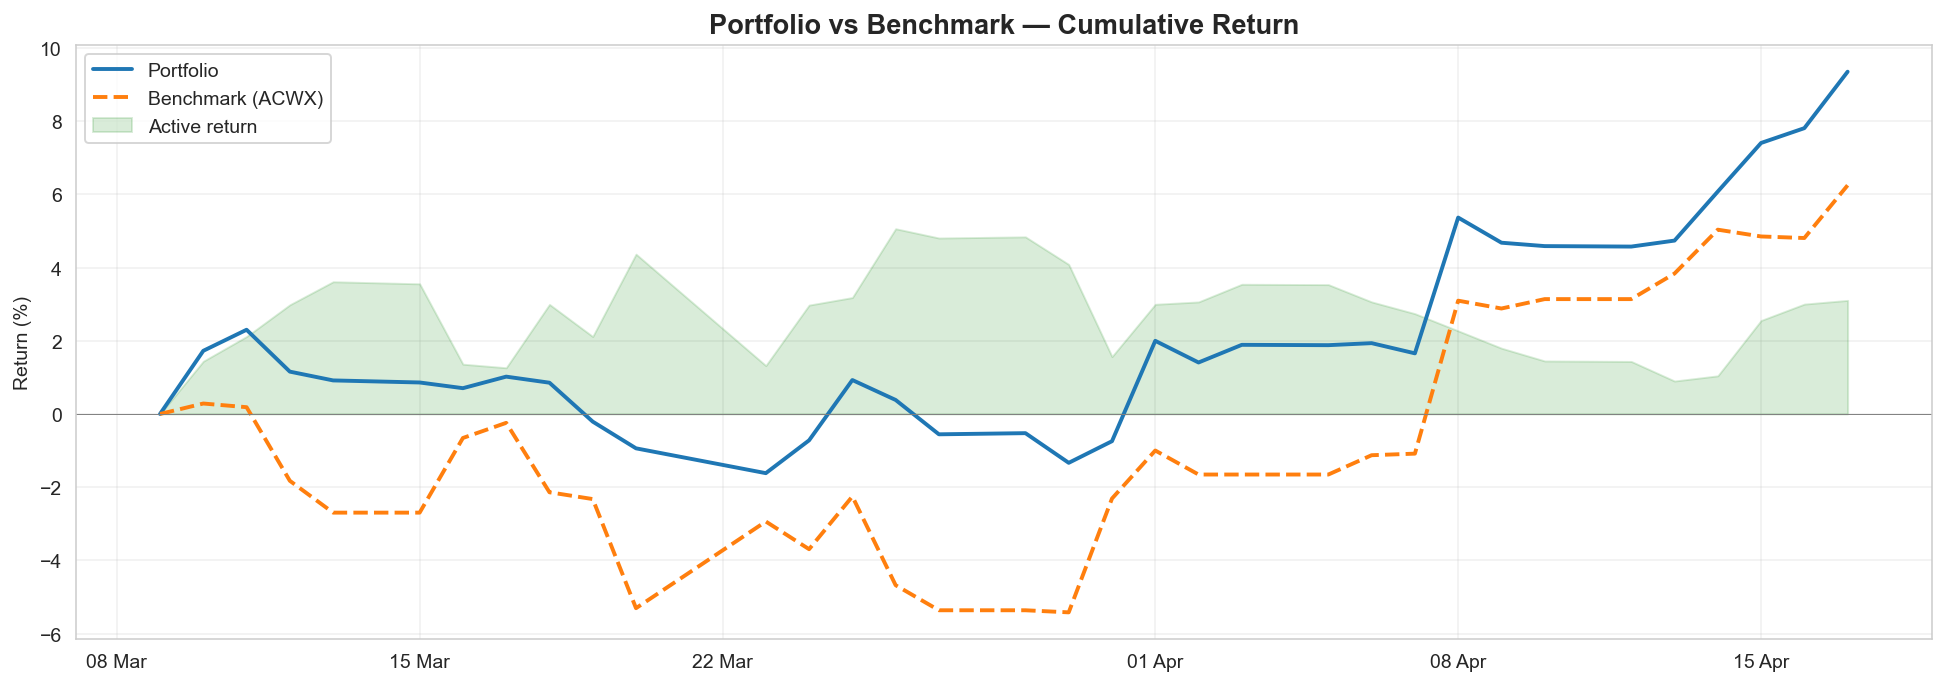

In [27]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(port_return.index, port_return * 100, linewidth=2, label="Portfolio", color="#1f77b4")
ax.plot(bench_return.index, bench_return * 100, linewidth=2, label=f"Benchmark ({BENCHMARK})", color="#ff7f0e", linestyle="--")
ax.axhline(0, color="grey", linewidth=0.5)
ax.fill_between(port_return.index,
                (port_return - bench_return) * 100, 0,
                alpha=0.15, color="green", label="Active return")
ax.set_title("Portfolio vs Benchmark — Cumulative Return", fontsize=14, fontweight="bold")
ax.set_ylabel("Return (%)")
ax.legend(loc="upper left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / "02_perf_vs_bench.png", dpi=160, bbox_inches="tight")
plt.show()

## 7 · Per-stock P&L table

In [28]:
latest_prices = prices[eq_tickers].iloc[-1]
pnl = positions.copy()
pnl["current_px"]    = pnl["ticker"].map(latest_prices)
pnl["current_value"] = pnl["shares"] * pnl["current_px"]
pnl["pnl"]           = pnl["current_value"] - pnl["cost_basis"]
pnl["return_pct"]    = pnl["pnl"] / pnl["cost_basis"] * 100
pnl["weight_now"]    = pnl["current_value"] / port_value.iloc[-1] * 100

pnl_full = pnl.sort_values("return_pct", ascending=False)

print(f"As of {prices.index[-1].date()} | Portfolio value: ${port_value.iloc[-1]:,.0f}\n")
print(tabulate(
    pnl_full[["name","ticker","country","tier","inception_px","current_px","pnl","return_pct","weight_now"]],
    headers=["Name","Ticker","Ctry","Tier","Entry Px","Curr Px","P&L ($)","Return %","Wt %"],
    tablefmt="simple", showindex=False,
    floatfmt=(".0f",".0f",".0f",".0f",".2f",".2f",",.0f","+.2f",".1f")))

print(f"\nTotal P&L: ${pnl_full['pnl'].sum():+,.0f}  |  "
      f"Winners: {(pnl_full['pnl'] > 0).sum()} / {len(pnl_full)}  |  "
      f"Losers: {(pnl_full['pnl'] < 0).sum()} / {len(pnl_full)}")

As of 2026-04-17 | Portfolio value: $1,093,535

Name               Ticker       Ctry      Tier    Entry Px    Curr Px    P&L ($)    Return %    Wt %
-----------------  -----------  ------  ------  ----------  ---------  ---------  ----------  ------
Maruwa Co          5344.T       JP           3    54362.29   69500.00      5,569      +27.85     2.3
King Slide Works   2059.TW      TW           2     3000.00    3640.00      9,600      +21.33     5.0
Technogym          TGYM.MI      IT           3       16.62      19.99      4,055      +20.28     2.2
Kakaku.com         2371.T       JP           1     1782.98    2144.50     16,221      +20.28     8.8
Games Workshop     GAW.L        GB           1    16849.05   20040.00     15,151      +18.94     8.7
Largan Precision   3008.TW      TW           2     2236.30    2605.00      7,419      +16.49     4.8
Odontoprev         ODPV3.SA     BR           1       13.71      15.78     12,079      +15.10     8.4
Recruit Holdings   6098.T       JP         

## 8 · Country & sector exposure

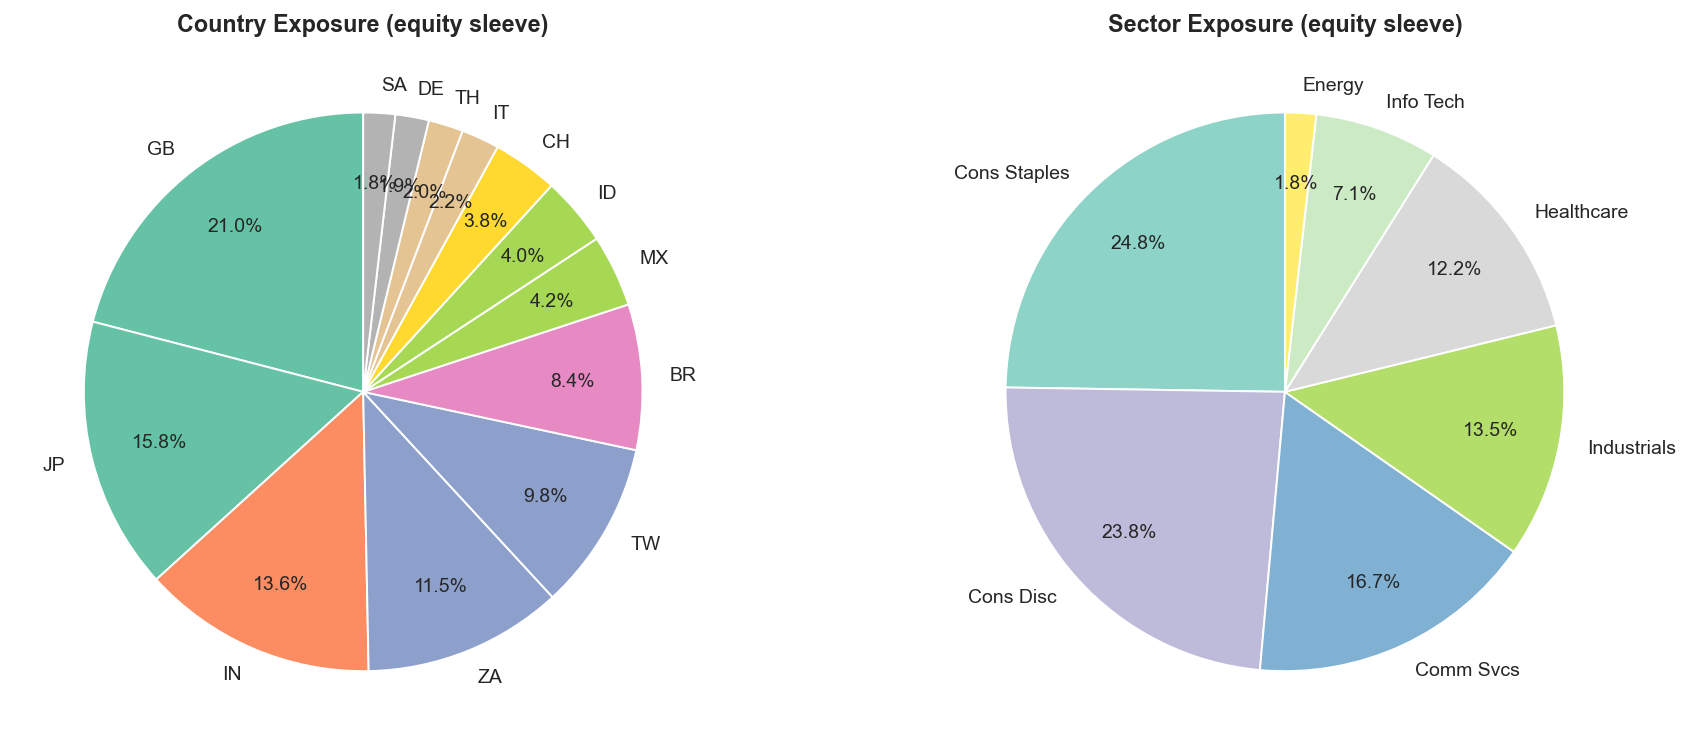


Country weights:
country
GB    21.0
JP    15.8
IN    13.6
ZA    11.5
TW     9.8
BR     8.4
MX     4.2
ID     4.0
CH     3.8
IT     2.2
TH     2.0
DE     1.9
SA     1.8

Sector weights:
sector
Cons Staples    24.8
Cons Disc       23.8
Comm Svcs       16.7
Industrials     13.5
Healthcare      12.2
Info Tech        7.1
Energy           1.8


In [29]:
# Current weights by country and sector (equity sleeve only)
eq_current = pnl[["name","country","sector","current_value"]].copy()
eq_total = eq_current["current_value"].sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Country pie
ctry = eq_current.groupby("country")["current_value"].sum().sort_values(ascending=False)
ctry_pct = ctry / eq_total * 100
colors_ctry = plt.cm.Set2(np.linspace(0, 1, len(ctry)))
wedges1, texts1, autotexts1 = ax1.pie(
    ctry_pct, labels=ctry.index, autopct="%1.1f%%", colors=colors_ctry,
    pctdistance=0.75, startangle=90)
ax1.set_title("Country Exposure (equity sleeve)", fontweight="bold")

# Sector pie
sec = eq_current.groupby("sector")["current_value"].sum().sort_values(ascending=False)
sec_pct = sec / eq_total * 100
colors_sec = plt.cm.Set3(np.linspace(0, 1, len(sec)))
wedges2, texts2, autotexts2 = ax2.pie(
    sec_pct, labels=sec.index, autopct="%1.1f%%", colors=colors_sec,
    pctdistance=0.75, startangle=90)
ax2.set_title("Sector Exposure (equity sleeve)", fontweight="bold")

plt.tight_layout()
plt.savefig(OUT / "02_exposure_pies.png", dpi=160, bbox_inches="tight")
plt.show()

print("\nCountry weights:")
print(ctry_pct.round(1).to_string())
print("\nSector weights:")
print(sec_pct.round(1).to_string())

## 9 · Drawdown analysis

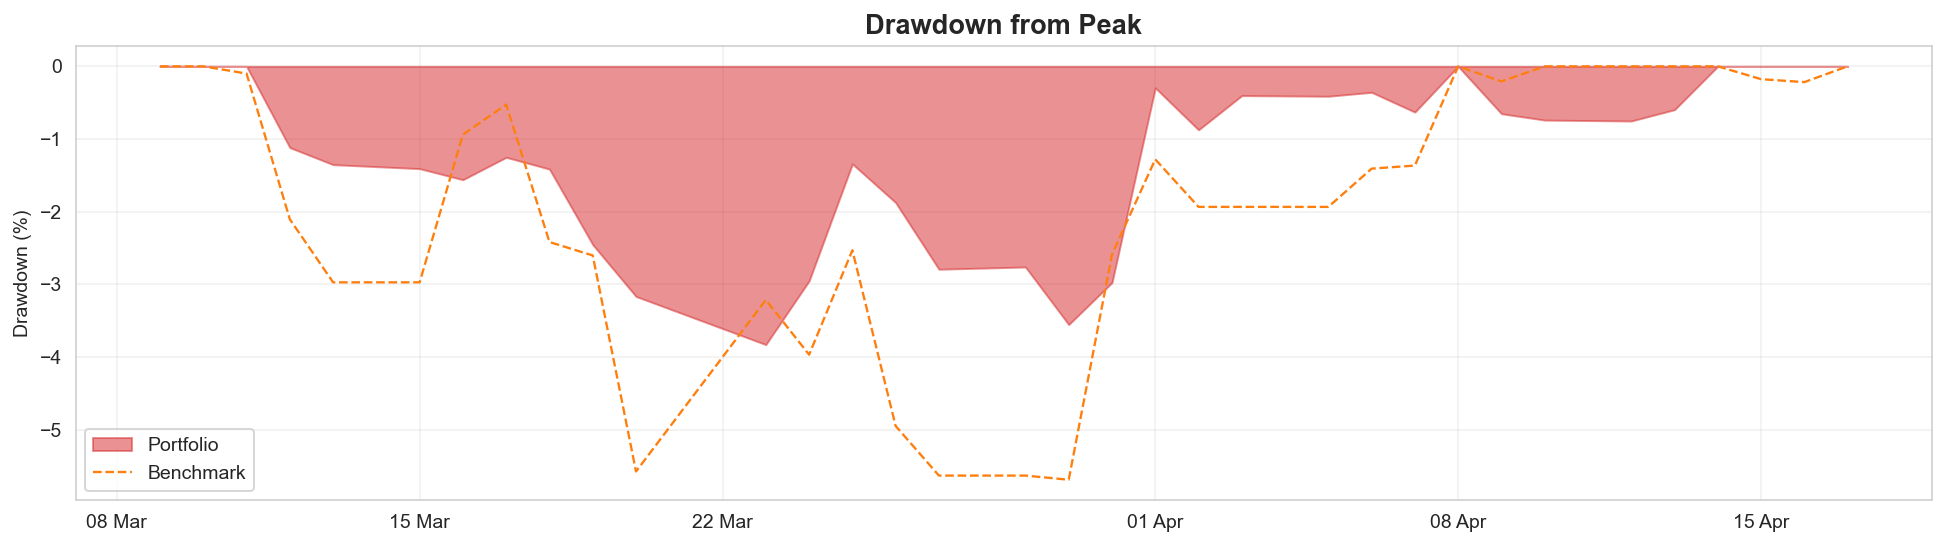

Max drawdown (portfolio): -3.83% on 2026-03-23
Max drawdown (benchmark): -5.69% on 2026-03-30


In [30]:
cum_max = port_value.cummax()
drawdown = (port_value - cum_max) / cum_max

bench_cum_max = prices[BENCHMARK].cummax()
bench_dd = (prices[BENCHMARK] - bench_cum_max) / bench_cum_max

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(drawdown.index, drawdown * 100, 0, alpha=0.5, color="#d62728", label="Portfolio")
ax.plot(bench_dd.index, bench_dd * 100, color="#ff7f0e", linewidth=1.2, linestyle="--", label="Benchmark")
ax.set_title("Drawdown from Peak", fontsize=14, fontweight="bold")
ax.set_ylabel("Drawdown (%)")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / "02_drawdown.png", dpi=160, bbox_inches="tight")
plt.show()

print(f"Max drawdown (portfolio): {drawdown.min():.2%} on {drawdown.idxmin().date()}")
print(f"Max drawdown (benchmark): {bench_dd.min():.2%} on {bench_dd.idxmin().date()}")

## 10 · Risk metrics & regression analysis

Computed over the live period (inception → latest). Annualised where appropriate, using 252 trading days.

In [31]:
# ── Align daily returns ──────────────────────────────────────
aligned = pd.DataFrame({
    "port":  port_daily_ret,
    "bench": bench_daily_ret,
}).dropna()

n_days = len(aligned)
ann_factor = 252
rf_daily = (1 + RISK_FREE_ANNUAL) ** (1/252) - 1

# ── Basic stats ──────────────────────────────────────────────
port_ann_ret  = (1 + aligned["port"].mean()) ** ann_factor - 1
bench_ann_ret = (1 + aligned["bench"].mean()) ** ann_factor - 1
port_ann_vol  = aligned["port"].std() * np.sqrt(ann_factor)
bench_ann_vol = aligned["bench"].std() * np.sqrt(ann_factor)

# ── Excess returns over risk-free ────────────────────────────
excess_port  = aligned["port"]  - rf_daily
excess_bench = aligned["bench"] - rf_daily
active_ret   = aligned["port"]  - aligned["bench"]

# ── Sharpe ratio ─────────────────────────────────────────────
sharpe       = excess_port.mean()  / aligned["port"].std()  * np.sqrt(ann_factor) if aligned["port"].std()  > 0 else np.nan
bench_sharpe = excess_bench.mean() / aligned["bench"].std() * np.sqrt(ann_factor) if aligned["bench"].std() > 0 else np.nan

# ── Tracking error & Information ratio ───────────────────────
tracking_error = active_ret.std() * np.sqrt(ann_factor)
info_ratio = active_ret.mean() / active_ret.std() * np.sqrt(ann_factor) if active_ret.std() > 0 else np.nan

# ── Beta & Treynor ───────────────────────────────────────────
cov_matrix = np.cov(aligned["port"], aligned["bench"])
beta = cov_matrix[0, 1] / cov_matrix[1, 1] if cov_matrix[1, 1] > 0 else np.nan
treynor       = (port_ann_ret  - RISK_FREE_ANNUAL) / beta if beta and beta != 0 else np.nan
bench_treynor = (bench_ann_ret - RISK_FREE_ANNUAL) / 1.0   # benchmark beta = 1

# ── Jensen's alpha (CAPM regression) ─────────────────────────
reg = sp_stats.linregress(aligned["bench"], aligned["port"])
alpha_daily = reg.intercept
alpha_ann   = alpha_daily * ann_factor  # approximate
r_squared   = reg.rvalue ** 2

# ── Sortino ratio ────────────────────────────────────────────
downside       = aligned["port"][aligned["port"] < 0]
downside_vol   = downside.std() * np.sqrt(ann_factor)   if len(downside)       > 0 else np.nan
sortino        = (port_ann_ret  - RISK_FREE_ANNUAL) / downside_vol if downside_vol and downside_vol > 0 else np.nan

bench_down     = aligned["bench"][aligned["bench"] < 0]
bench_down_vol = bench_down.std() * np.sqrt(ann_factor) if len(bench_down)     > 0 else np.nan
bench_sortino  = (bench_ann_ret - RISK_FREE_ANNUAL) / bench_down_vol if bench_down_vol and bench_down_vol > 0 else np.nan

# ── Calmar ratio ─────────────────────────────────────────────
max_dd       = abs(drawdown.min())
bench_max_dd = abs(bench_dd.min())
calmar       = (port_ann_ret  - RISK_FREE_ANNUAL) / max_dd       if max_dd       > 0 else np.nan
bench_calmar = (bench_ann_ret - RISK_FREE_ANNUAL) / bench_max_dd if bench_max_dd > 0 else np.nan

# ── Up/Down capture ──────────────────────────────────────────
up_days   = aligned[aligned["bench"] > 0]
down_days = aligned[aligned["bench"] < 0]
up_capture   = (up_days["port"].mean()   / up_days["bench"].mean()   * 100) if len(up_days)   > 0 else np.nan
down_capture = (down_days["port"].mean() / down_days["bench"].mean() * 100) if len(down_days) > 0 else np.nan

# ── Daily std dev ────────────────────────────────────────────
port_daily_std  = aligned["port"].std()
bench_daily_std = aligned["bench"].std()

# ── Summary table — full comparison ──────────────────────────
risk_metrics = pd.DataFrame([
    ["Annualised return",       f"{port_ann_ret:.2%}",       f"{bench_ann_ret:.2%}"],
    ["Annualised volatility",   f"{port_ann_vol:.2%}",       f"{bench_ann_vol:.2%}"],
    ["Daily std dev",           f"{port_daily_std:.4%}",     f"{bench_daily_std:.4%}"],
    ["Sharpe ratio",            f"{sharpe:.2f}",             f"{bench_sharpe:.2f}"],
    ["Sortino ratio",           f"{sortino:.2f}",            f"{bench_sortino:.2f}"],
    ["Treynor ratio",           f"{treynor:.4f}",            f"{bench_treynor:.4f}"],
    ["Calmar ratio",            f"{calmar:.2f}",             f"{bench_calmar:.2f}"],
    ["Information ratio",       f"{info_ratio:.2f}",         "—"],
    ["Tracking error (ann)",    f"{tracking_error:.2%}",     "—"],
    ["Beta (vs benchmark)",     f"{beta:.3f}",               "1.000"],
    ["Jensen's alpha (ann)",    f"{alpha_ann:.2%}",          "0.00%"],
    ["R-squared",               f"{r_squared:.3f}",          "1.000"],
    ["Max drawdown",            f"{drawdown.min():.2%}",     f"{bench_dd.min():.2%}"],
    ["Downside volatility",     f"{downside_vol:.2%}",       f"{bench_down_vol:.2%}"],
    ["Up capture ratio",        f"{up_capture:.1f}%",        "100.0%"],
    ["Down capture ratio",      f"{down_capture:.1f}%",      "100.0%"],
    ["Trading days",            f"{n_days}",                 f"{n_days}"],
], columns=["Metric", "Portfolio", f"Benchmark ({BENCHMARK})"])

print(tabulate(risk_metrics, headers="keys", tablefmt="simple", showindex=False))

Metric                 Portfolio    Benchmark (ACWX)
---------------------  -----------  ------------------
Annualised return      100.76%      63.26%
Annualised volatility  17.20%       23.81%
Daily std dev          1.0835%      1.5001%
Sharpe ratio           3.81         1.88
Sortino ratio          16.07        3.71
Treynor ratio          2.2610       0.5896
Calmar ratio           25.18        10.36
Information ratio      1.06         —
Tracking error (ann)   19.47%       —
Beta (vs benchmark)    0.427        1.000
Jensen's alpha (ann)   48.86%       0.00%
R-squared              0.349        1.000
Max drawdown           -3.83%       -5.69%
Downside volatility    6.00%        15.89%
Up capture ratio       63.1%        100.0%
Down capture ratio     28.1%        100.0%
Trading days           33           33


## 11 · CAPM regression plot

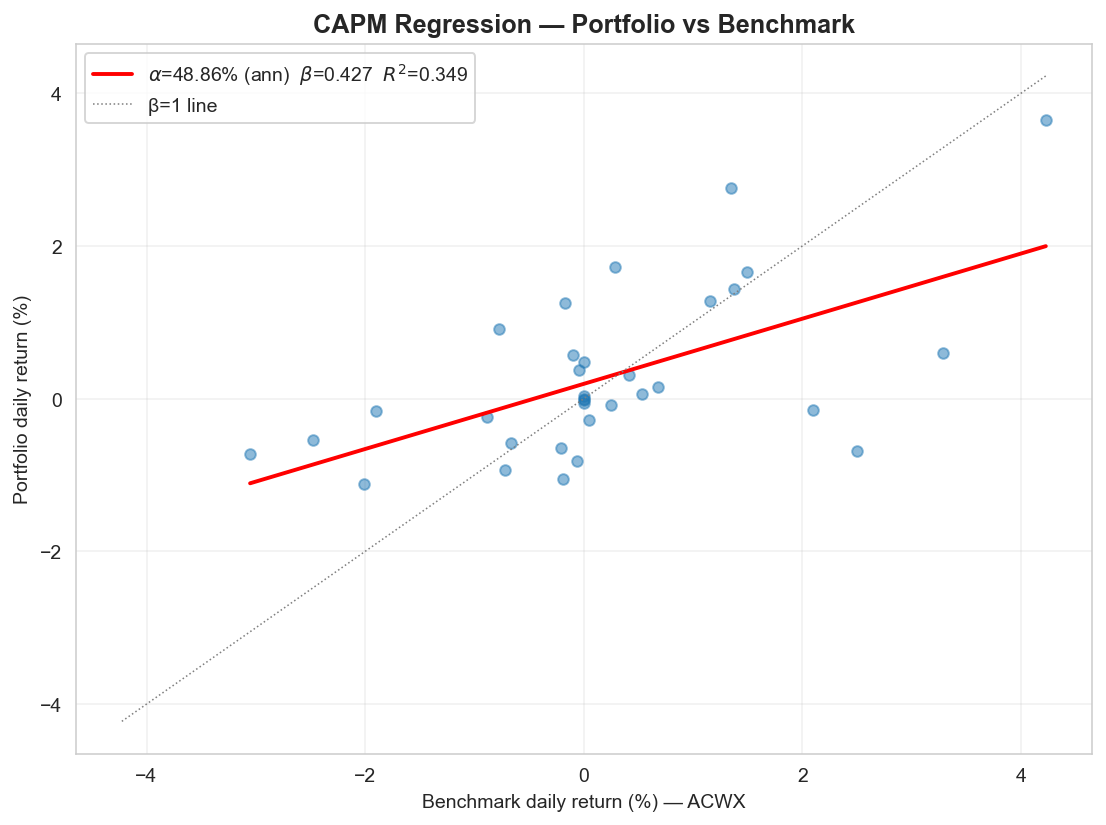

In [32]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(aligned["bench"] * 100, aligned["port"] * 100, alpha=0.5, s=30, color="#1f77b4")

# Regression line
x_line = np.linspace(aligned["bench"].min(), aligned["bench"].max(), 100) * 100
y_line = (reg.intercept + reg.slope * np.linspace(aligned["bench"].min(), aligned["bench"].max(), 100)) * 100
ax.plot(x_line, y_line, color="red", linewidth=2,
        label=f"$\\alpha$={alpha_ann:.2%} (ann)  $\\beta$={beta:.3f}  $R^2$={r_squared:.3f}")

# 45-degree line
lim = max(abs(aligned["bench"].min()), abs(aligned["bench"].max())) * 100
ax.plot([-lim, lim], [-lim, lim], color="grey", linewidth=0.8, linestyle=":", label="β=1 line")

ax.set_xlabel(f"Benchmark daily return (%) — {BENCHMARK}")
ax.set_ylabel("Portfolio daily return (%)")
ax.set_title("CAPM Regression — Portfolio vs Benchmark", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / "02_capm_regression.png", dpi=160, bbox_inches="tight")
plt.show()

## 12 · Correlation heatmap

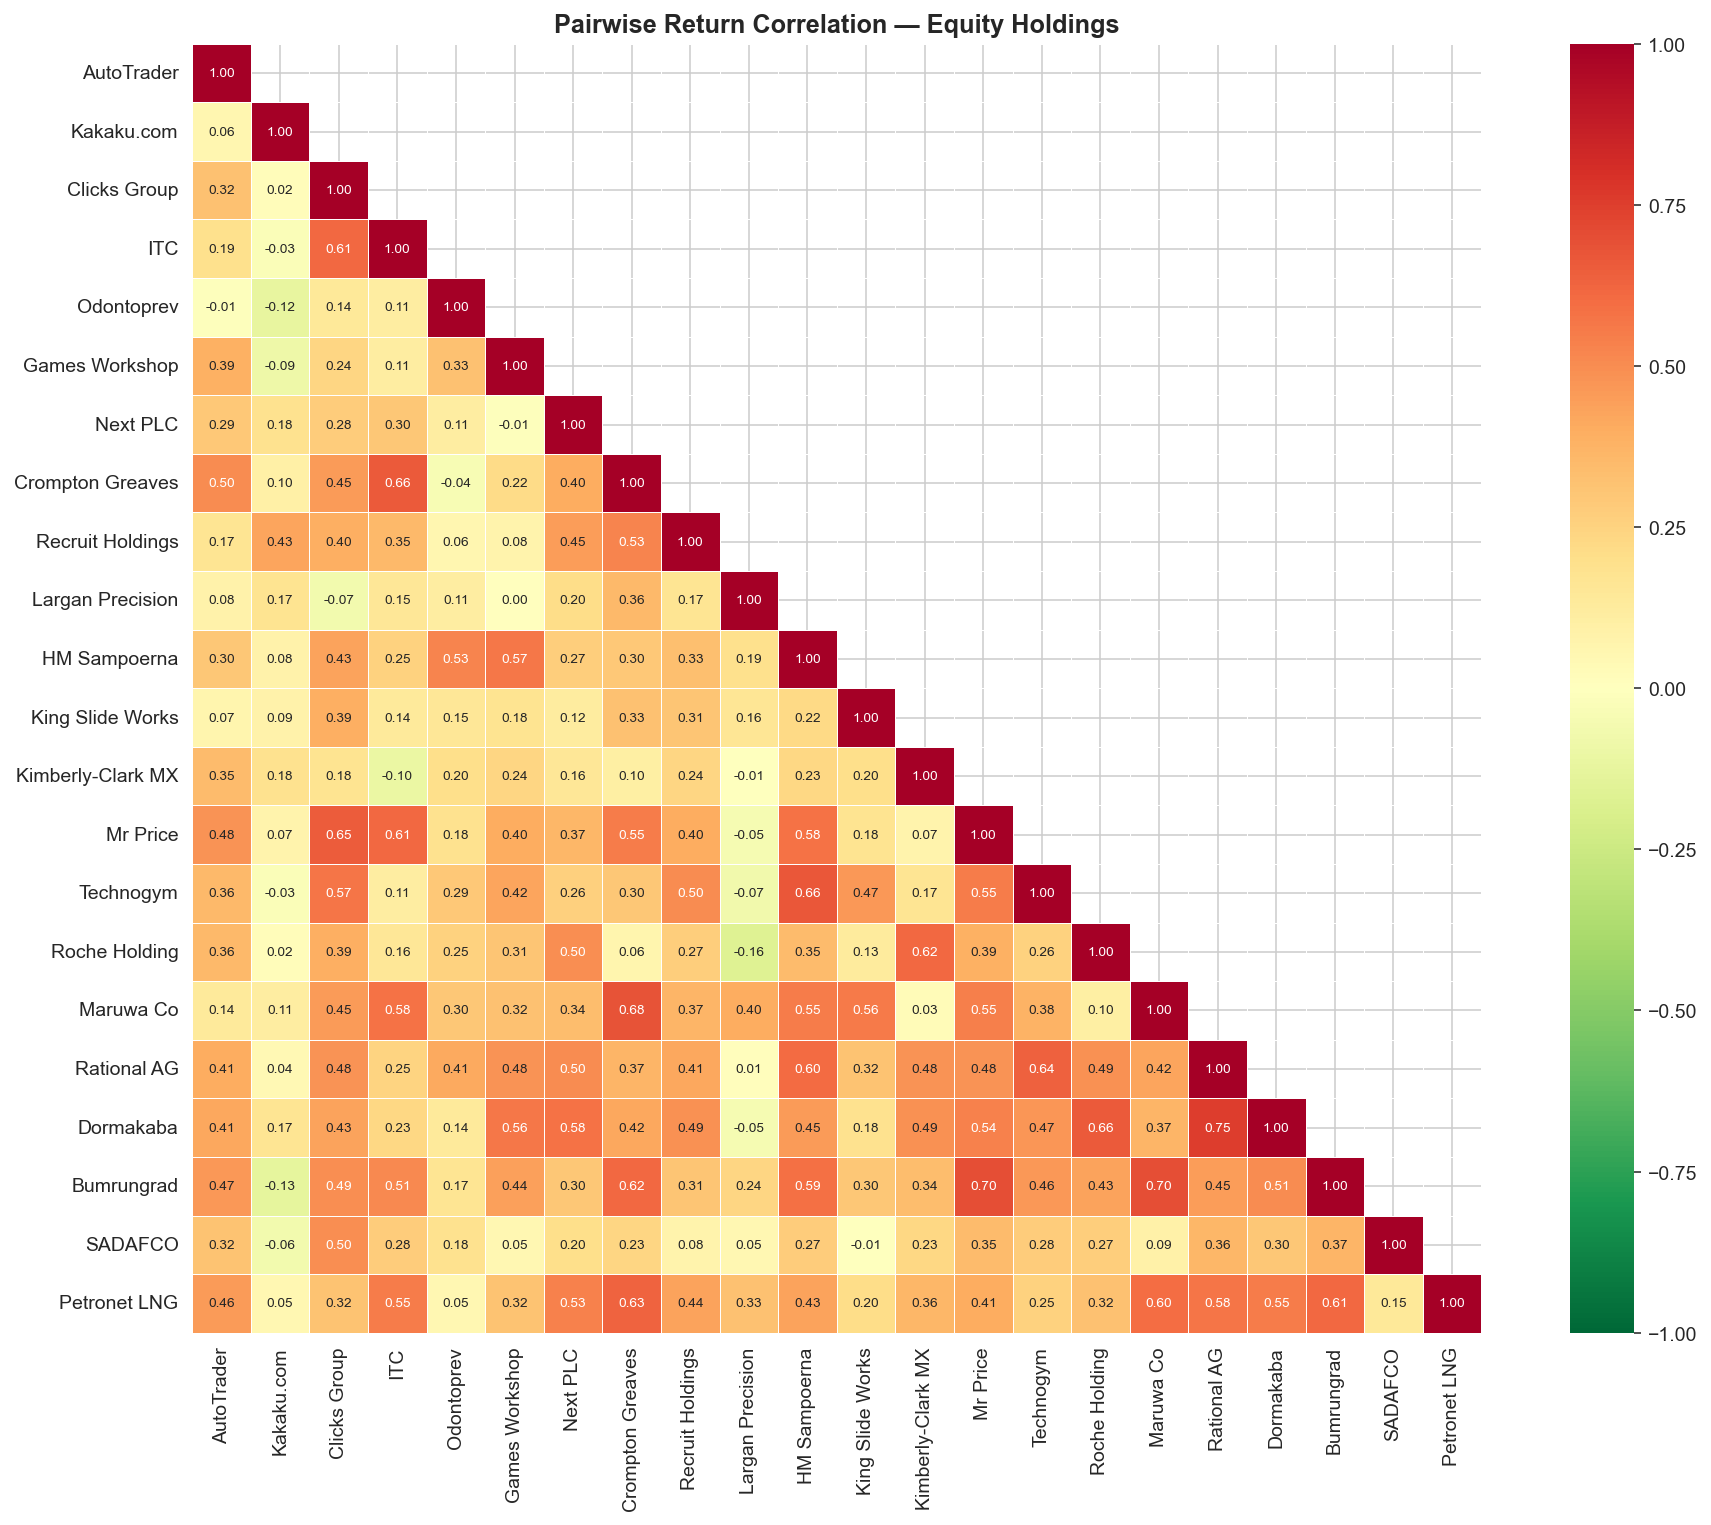

Average pairwise correlation: 0.303


In [33]:
# Daily returns for all equity holdings
eq_daily_ret = prices[eq_tickers].pct_change().dropna()
eq_daily_ret.columns = [HOLDINGS.set_index("ticker").loc[t, "name"] for t in eq_tickers]

corr = eq_daily_ret.corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn_r",
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            square=True, ax=ax, annot_kws={"size": 7})
ax.set_title("Pairwise Return Correlation — Equity Holdings", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT / "02_corr_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()

# Average pairwise correlation
avg_corr = corr.where(~np.eye(len(corr), dtype=bool)).stack().mean()
print(f"Average pairwise correlation: {avg_corr:.3f}")

## 13 · Dividend yield — current & trailing

In [34]:
def _safe_yield(info):
    """Return (trailing_yield, forward_yield) as decimals.
    yfinance dividendYield is unreliable for some non-US tickers
    (e.g. 2059.TW returns 0.88 meaning 88%). Cross-validate against
    trailingAnnualDividendYield and dividendRate/price."""
    def _to_float(v):
        if v is None:
            return np.nan
        try:
            v = float(v)
        except (TypeError, ValueError):
            return np.nan
        return np.nan if np.isnan(v) else v

    trail = _to_float(info.get("trailingAnnualDividendYield"))
    fwd   = _to_float(info.get("dividendYield"))

    # Compute forward yield from rate / price as ground truth
    rate  = _to_float(info.get("dividendRate"))
    px    = _to_float(info.get("currentPrice")) or _to_float(info.get("regularMarketPrice"))
    computed_fwd = rate / px if (not np.isnan(rate) and px and px > 0) else np.nan

    # Fix fwd: if we have a computed value and fwd disagrees by >5x, replace it
    if not np.isnan(computed_fwd):
        if np.isnan(fwd) or abs(fwd - computed_fwd) / max(computed_fwd, 1e-9) > 5:
            fwd = computed_fwd
    # Also fix: if trailing exists and fwd > 10 * trailing, it's bogus
    if not np.isnan(trail) and not np.isnan(fwd) and trail > 0:
        if fwd / trail > 10:
            fwd = trail  # fallback to trailing

    # Normalise: if still > 1, it was in % form
    if not np.isnan(trail) and trail > 1:
        trail = trail / 100
    if not np.isnan(fwd) and fwd > 1:
        fwd = fwd / 100

    return trail, fwd

div_data = []
for _, h in HOLDINGS.iterrows():
    t = yf.Ticker(h["ticker"])
    info = t.info
    trail, fwd = _safe_yield(info)
    pr = info.get("payoutRatio")
    if pr is not None and not (isinstance(pr, float) and np.isnan(pr)):
        pr = pr / 100 if pr > 1 else pr
    else:
        pr = np.nan
    div_data.append({
        "name":           h["name"],
        "ticker":         h["ticker"],
        "trailing_yield": trail,
        "forward_yield":  fwd,
        "payout_ratio":   pr,
        "ex_date":        info.get("exDividendDate", None),
    })

div_df = pd.DataFrame(div_data)
div_df["trailing_yield"] = (div_df["trailing_yield"] * 100).round(2)
div_df["forward_yield"]  = (div_df["forward_yield"]  * 100).round(2)
div_df["payout_ratio"]   = (div_df["payout_ratio"]   * 100).round(1)

# Portfolio-weighted yield (conviction-weighted)
div_df_merged = div_df.merge(HOLDINGS[["ticker","eq_weight"]], on="ticker")
port_trail_yield = (div_df_merged["trailing_yield"] * div_df_merged["eq_weight"]).sum()
port_fwd_yield   = (div_df_merged["forward_yield"]  * div_df_merged["eq_weight"]).sum()

print(tabulate(div_df, headers="keys", tablefmt="simple", showindex=False))
print(f"\nPortfolio weighted trailing yield: {port_trail_yield:.2f}%")
print(f"Portfolio weighted forward yield:  {port_fwd_yield:.2f}%")

name               ticker         trailing_yield    forward_yield    payout_ratio     ex_date
-----------------  -----------  ----------------  ---------------  --------------  ----------
AutoTrader         AUTO.L                   0.02             0.02            31.9  1767312000
Kakaku.com         2371.T                   2.35             2.33            49.9  1774828800
Clicks Group       CLS.JO                   0.03             0.03            59    1768953600
ITC                ITC.NS                   4.73             4.68            88.2  1770163200
Odontoprev         ODPV3.SA                 5.15             6.34            90.1  1766102400
Games Workshop     GAW.L                    0.03             0.02            89.7  1776297600
Next PLC           NXT.L                    0.02             0.02            32.9  1782950400
Crompton Greaves   CROMPTON.NS              0                1.15            41.9  1753315200
Recruit Holdings   6098.T                   0.34            

## 14 · Key fundamentals summary table

In [35]:
# ── Pull yfinance fundamentals for ALL 22 stocks ─────────────
print("Fetching yfinance fundamentals for all 22 holdings...")
yf_data = []
for _, h in HOLDINGS.iterrows():
    try:
        info = yf.Ticker(h["ticker"]).info
        _, fwd_y = _safe_yield(info)  # reuse cross-validated yield
        yf_data.append({
            "ticker":       h["ticker"],
            "yf_pe":        info.get("trailingPE") or info.get("forwardPE"),
            "yf_div_yield": fwd_y,
            "yf_roe":       info.get("returnOnEquity"),          # proxy for ROIC
            "yf_d2e":       (info.get("debtToEquity") or 0) / 100 if info.get("debtToEquity") is not None else np.nan,
            "yf_payout":    info.get("payoutRatio"),
            "yf_beta":      info.get("beta"),
            "yf_margin":    info.get("profitMargins"),
            "yf_rev_growth":info.get("revenueGrowth"),
        })
    except Exception as e:
        print(f"  {h['ticker']}: {e}")
        yf_data.append({"ticker": h["ticker"]})

yf_df = pd.DataFrame(yf_data)
print(f"  Done — {len(yf_df)} tickers fetched\n")

# ── Merge P&L + Compustat screen + yfinance ──────────────────
summary = positions[["name","ticker","country","sector","tier"]].merge(
    pnl[["ticker","return_pct","weight_now"]], on="ticker"
).merge(
    fundamentals.reset_index()[["ticker","piotroski","roic_5y_avg","fcf_ev_5y_avg",
                                 "div_yield","pe_ratio","net_debt_ebitda","composite"]],
    on="ticker", how="left"
).merge(yf_df, on="ticker", how="left")

# ── For stocks missing from screen CSV, fill with yfinance ───
mask_no_screen = summary["composite"].isna()
summary.loc[mask_no_screen, "pe_ratio"]        = summary.loc[mask_no_screen, "yf_pe"]
summary.loc[mask_no_screen, "div_yield"]       = summary.loc[mask_no_screen, "yf_div_yield"]
summary.loc[mask_no_screen, "roic_5y_avg"]     = summary.loc[mask_no_screen, "yf_roe"]
summary.loc[mask_no_screen, "net_debt_ebitda"] = summary.loc[mask_no_screen, "yf_d2e"]

# ── Format for display ───────────────────────────────────────
summary["return_pct"]    = summary["return_pct"].round(1)
summary["weight_now"]    = summary["weight_now"].round(1)
summary["composite"]     = summary["composite"].round(2)

# Compustat columns (already in decimal from screen CSV)
summary["roic_5y_avg"]     = (summary["roic_5y_avg"]   * 100).round(1)
summary["fcf_ev_5y_avg"]   = (summary["fcf_ev_5y_avg"] * 100).round(1)
summary["div_yield"]       = (summary["div_yield"]     * 100).round(1)
summary["net_debt_ebitda"] = summary["net_debt_ebitda"].round(1)
summary["pe_ratio"]        = summary["pe_ratio"].round(1)

# yfinance columns (in decimal)
summary["yf_roe"]        = (summary["yf_roe"]       * 100).round(1)
summary["yf_div_yield"]  = (summary["yf_div_yield"] * 100).round(1)
summary["yf_margin"]     = (summary["yf_margin"]    * 100).round(1)
summary["yf_rev_growth"] = (summary["yf_rev_growth"]* 100).round(1)
summary["yf_pe"]         = summary["yf_pe"].round(1)
summary["yf_d2e"]        = summary["yf_d2e"].round(2)
summary["yf_beta"]       = summary["yf_beta"].round(2)

summary = summary.sort_values("composite", ascending=False, na_position="last")

# ── Table 1: Main fundamentals (Compustat + yfinance fill) ───
print("─" * 100)
print("TABLE 1 — Key Fundamentals (Compustat screen; yfinance fill for 7 non-screen stocks)")
print("─" * 100)
print(tabulate(
    summary[["name","country","tier","return_pct","weight_now","composite",
             "piotroski","roic_5y_avg","fcf_ev_5y_avg","div_yield","pe_ratio","net_debt_ebitda"]],
    headers=["Name","Ctry","T","Ret%","Wt%","Comp","Pio","ROIC%","FCF/EV%","DivY%","PE","ND/EB"],
    tablefmt="simple", showindex=False, missingval="—"))

# ── Table 2: yfinance cross-check ────────────────────────────
print(f"\n{'─' * 100}")
print("TABLE 2 — yfinance Cross-Check (live data for all 22 stocks)")
print("─" * 100)
print(tabulate(
    summary[["name","yf_pe","yf_div_yield","yf_roe","yf_d2e","yf_margin","yf_rev_growth","yf_beta"]],
    headers=["Name","PE(yf)","DivY%(yf)","ROE%(yf)","D/E(yf)","Margin%(yf)","RevGr%(yf)","Beta(yf)"],
    tablefmt="simple", showindex=False, missingval="—"))

# ── Table 3: Side-by-side comparison where both sources exist ─
has_both = summary[summary["composite"].notna()].copy()
if len(has_both) > 0:
    compare = has_both[["name"]].copy()
    compare["PE_screen"]   = has_both["pe_ratio"]
    compare["PE_yf"]       = has_both["yf_pe"]
    compare["DivY_screen"] = has_both["div_yield"]
    compare["DivY_yf"]     = has_both["yf_div_yield"]
    compare["ROIC_screen"] = has_both["roic_5y_avg"]
    compare["ROE_yf"]      = has_both["yf_roe"]
    compare["ND/EB_screen"]= has_both["net_debt_ebitda"]
    compare["D/E_yf"]      = has_both["yf_d2e"]

    print(f"\n{'─' * 100}")
    print(f"TABLE 3 — Compustat vs yfinance ({len(has_both)} stocks with both sources)")
    print("─" * 100)
    print(tabulate(compare, headers="keys", tablefmt="simple", showindex=False, missingval="—"))
    print("\nNote: ROIC (Compustat 5yr avg) vs ROE (yfinance current) — different metrics, directionally comparable")
    print("      ND/EBITDA (Compustat) vs D/E (yfinance) — different leverage ratios, both measure indebtedness")

Fetching yfinance fundamentals for all 22 holdings...
  Done — 22 tickers fetched

────────────────────────────────────────────────────────────────────────────────────────────────────
TABLE 1 — Key Fundamentals (Compustat screen; yfinance fill for 7 non-screen stocks)
────────────────────────────────────────────────────────────────────────────────────────────────────
Name               Ctry      T    Ret%    Wt%    Comp    Pio    ROIC%    FCF/EV%    DivY%    PE    ND/EB
-----------------  ------  ---  ------  -----  ------  -----  -------  ---------  -------  ----  -------
AutoTrader         GB        1     8.3    7.9    0.77      9     45.2        4.1      3    14.1      0
Kakaku.com         JP        1    20.3    8.8    0.73      6     82.8        5        2.8  17.9      0
Clicks Group       ZA        1     1.4    7.4    0.73      8     40          4.4      5.7  11.2      0.1
Odontoprev         BR        1    15.1    8.4    0.72      8     54.8       11.1      7    12.8      0
Next P

## 15 · Per-stock price charts (sparklines)

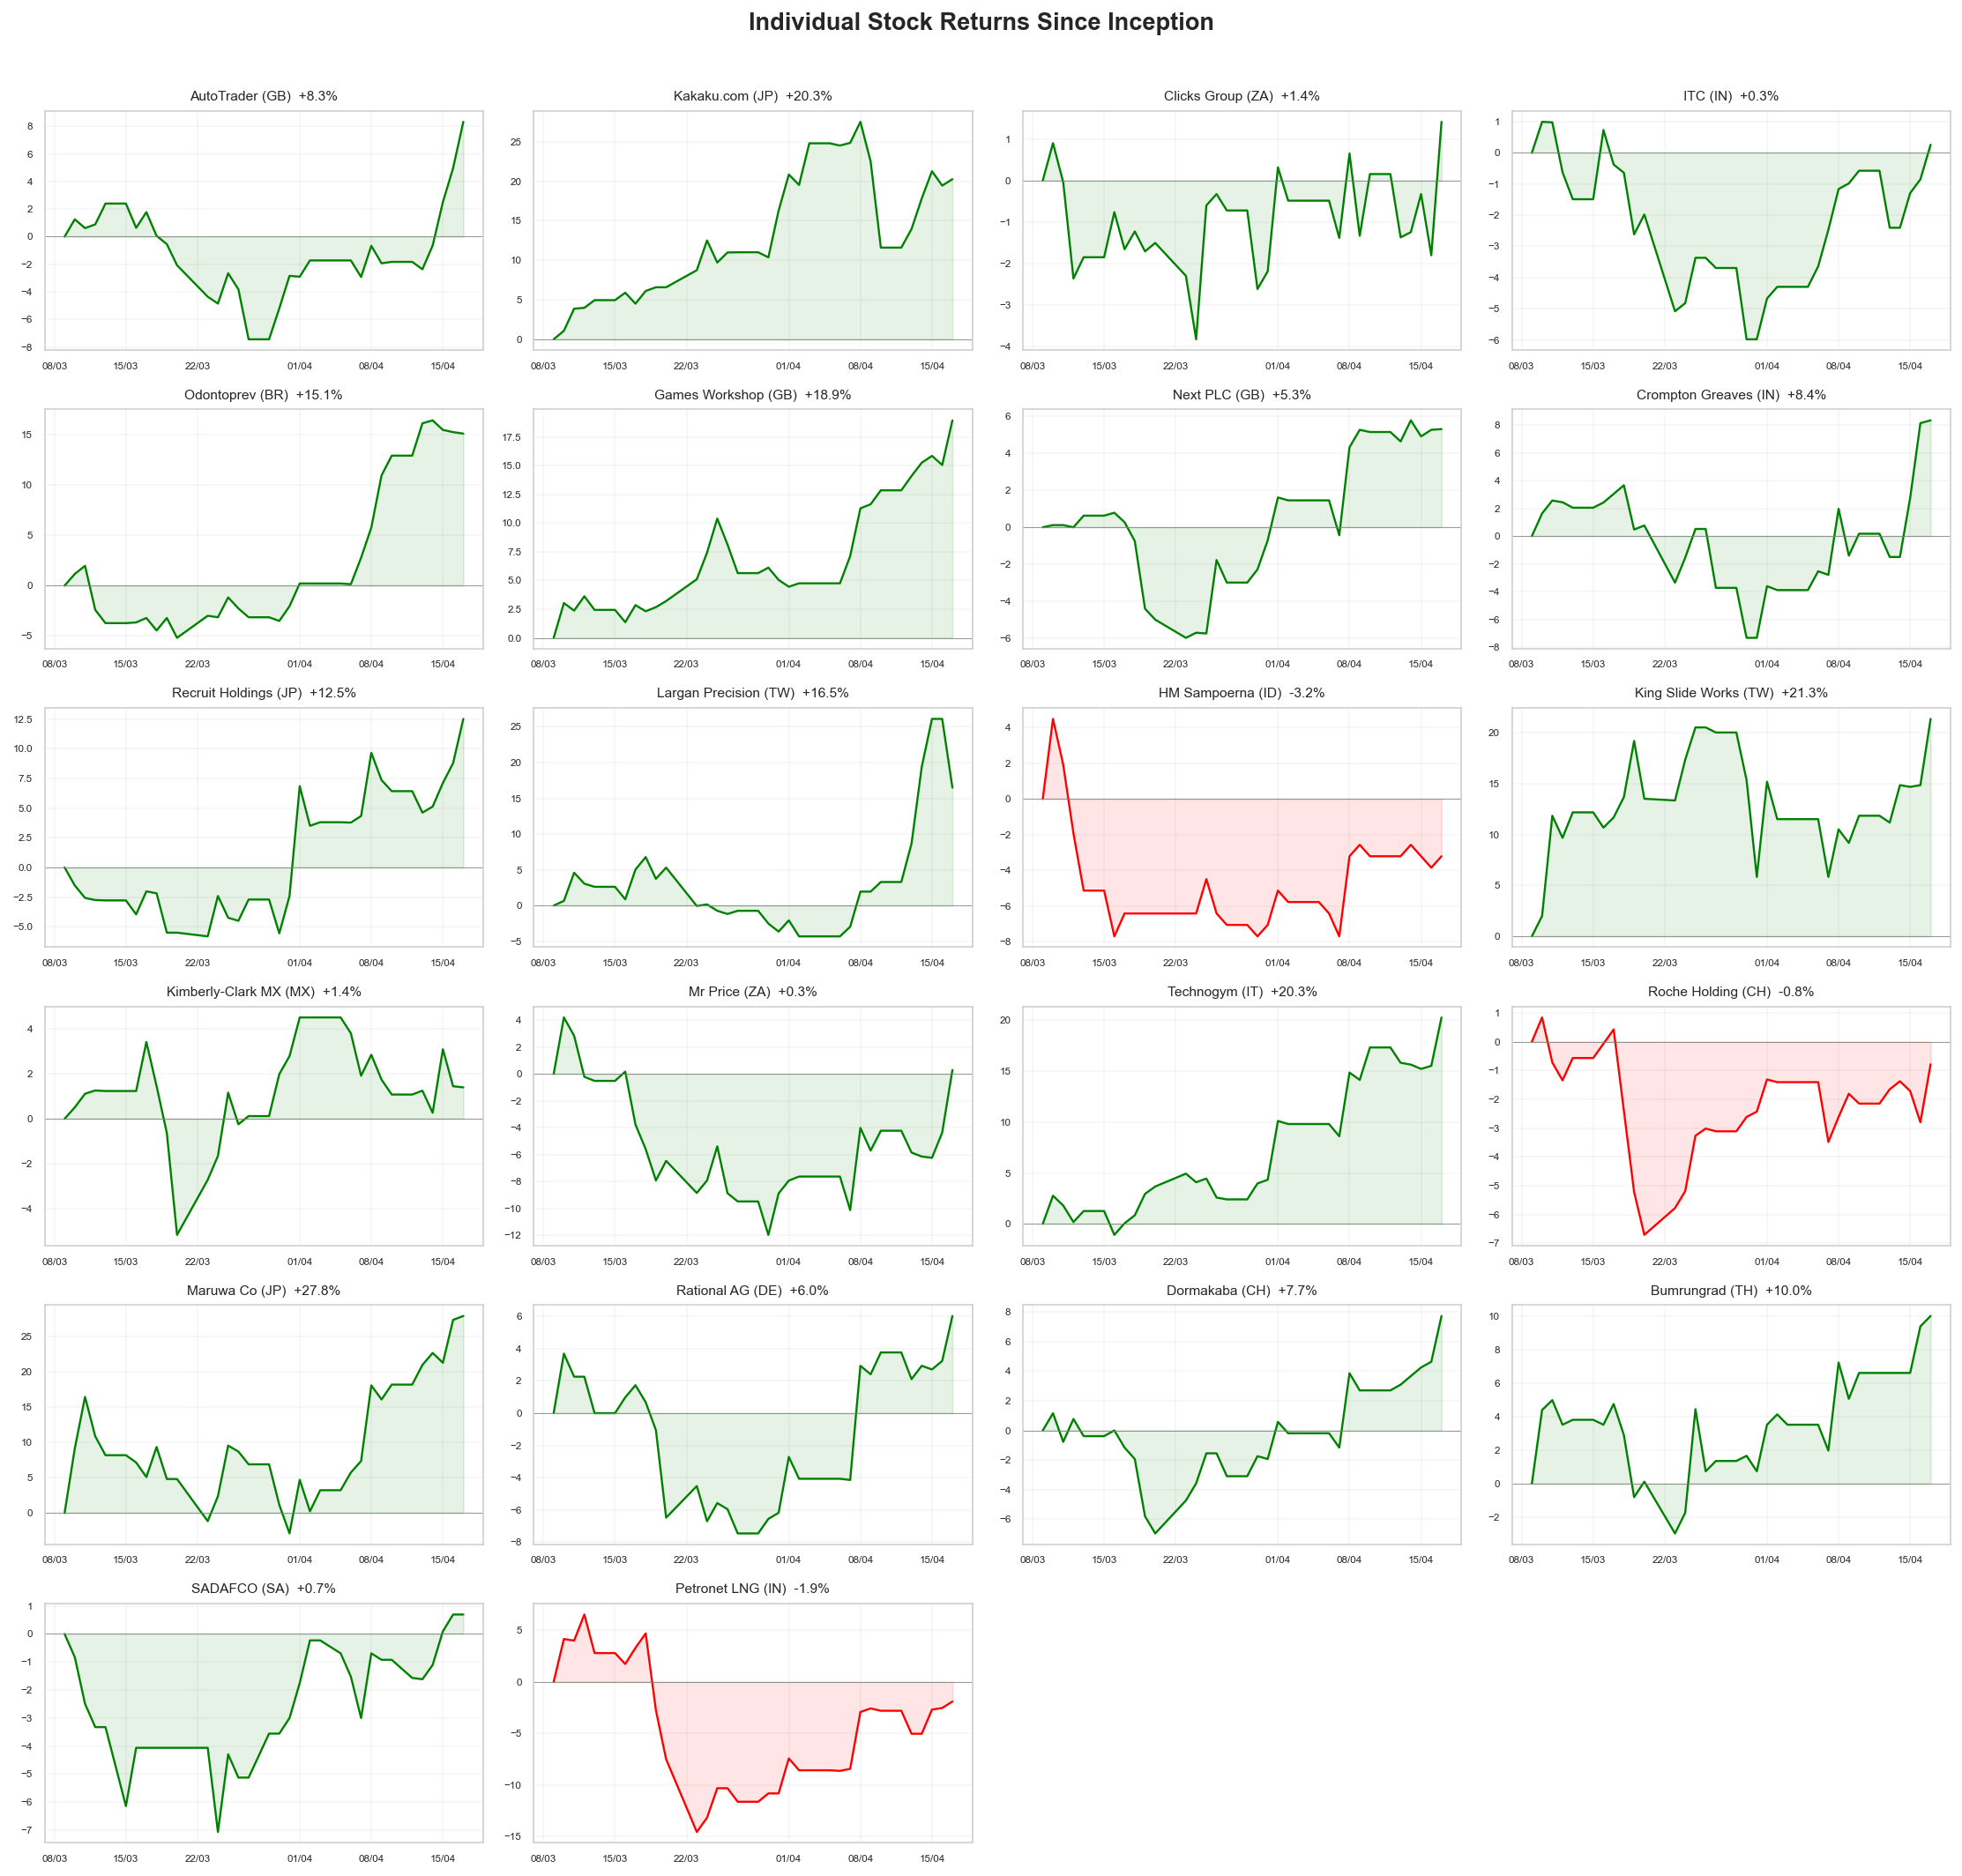

In [36]:
n_cols = 4
n_rows = int(np.ceil(N_STOCKS / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 2.5))
axes = axes.flatten()

palette = plt.cm.tab20(np.linspace(0, 1, N_STOCKS))

for i, (_, h) in enumerate(HOLDINGS.iterrows()):
    ax = axes[i]
    ret = stock_returns[h["ticker"]] * 100
    color = "green" if ret.iloc[-1] >= 0 else "red"
    ax.plot(ret.index, ret, linewidth=1.2, color=color)
    ax.fill_between(ret.index, ret, 0, alpha=0.1, color=color)
    ax.axhline(0, color="grey", linewidth=0.4)
    ax.set_title(f"{h['name']} ({h['country']})  {ret.iloc[-1]:+.1f}%", fontsize=8)
    ax.tick_params(labelsize=6)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
    ax.grid(True, alpha=0.2)

# Hide unused axes
for j in range(N_STOCKS, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Individual Stock Returns Since Inception", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(OUT / "02_stock_sparklines.png", dpi=160, bbox_inches="tight")
plt.show()

## 16 · Trade log / journal

Initial trade entries. Append new rows manually for any future trades (the mandate says no rebalancing, but this is here if you need to record observations or dividends received).

In [37]:
# ── Initialise trade log with inception buys ─────────────────
trade_log = []
for _, pos in positions.iterrows():
    trade_log.append({
        "date":      INCEPTION,
        "action":    "BUY",
        "ticker":    pos["ticker"],
        "name":      pos["name"],
        "tier":      int(pos["tier"]),
        "shares":    round(pos["shares"], 4),
        "price":     round(pos["inception_px"], 4),
        "value":     round(pos["cost_basis"], 2),
        "notes":     f"Inception — Tier {int(pos['tier'])} ({pos['weight']:.1%})",
    })

trade_log_df = pd.DataFrame(trade_log)

# Save to CSV so it persists
log_path = OUT / "trade_log.csv"
trade_log_df.to_csv(log_path, index=False)
print(f"Trade log saved → {log_path}")
print(f"\n{len(trade_log_df)} entries:")
print(tabulate(trade_log_df, headers="keys", tablefmt="simple", showindex=False,
               floatfmt=(".0f",".0f",".0f",".0f",".0f",".4f",".4f",",.2f",".0f")))

Trade log saved → /Users/conradgreen/Documents/SIA_Portfolio/data/outputs/trade_log.csv

22 entries:
date        action    ticker       name                 tier     shares       price      value  notes
----------  --------  -----------  -----------------  ------  ---------  ----------  ---------  -------------------------
2026-03-09  BUY       AUTO.L       AutoTrader              1   165.5629    483.2000  80,000.00  Inception — Tier 1 (8.0%)
2026-03-09  BUY       2371.T       Kakaku.com              1    44.8687   1782.9819  80,000.00  Inception — Tier 1 (8.0%)
2026-03-09  BUY       CLS.JO       Clicks Group            1     2.7032  29595.0000  80,000.00  Inception — Tier 1 (8.0%)
2026-03-09  BUY       ITC.NS       ITC                     1   261.4379    306.0000  80,000.00  Inception — Tier 1 (8.0%)
2026-03-09  BUY       ODPV3.SA     Odontoprev              1  5835.1568     13.7100  80,000.00  Inception — Tier 1 (8.0%)
2026-03-09  BUY       GAW.L        Games Workshop          1     

## 17 · Portfolio snapshot — persist to CSV

In [38]:
snapshot = pnl_full[["name","ticker","country","sector",
                      "inception_px","current_px","shares",
                      "cost_basis","current_value","pnl","return_pct","weight_now"]].copy()
snapshot["snapshot_date"] = prices.index[-1].date()
snapshot.to_csv(OUT / "portfolio_snapshot.csv", index=False)

# Also save the risk metrics
risk_metrics.to_csv(OUT / "risk_metrics.csv", index=False)

print(f"Saved:")
print(f"  portfolio_snapshot.csv  ({len(snapshot)} rows)")
print(f"  risk_metrics.csv       ({len(risk_metrics)} rows)")
print(f"  trade_log.csv          ({len(trade_log_df)} rows)")
print(f"\nDashboard charts saved to {OUT}/02_*.png")

Saved:
  portfolio_snapshot.csv  (22 rows)
  risk_metrics.csv       (17 rows)
  trade_log.csv          (22 rows)

Dashboard charts saved to /Users/conradgreen/Documents/SIA_Portfolio/data/outputs/02_*.png
